In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [12]:
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3)


In [13]:
x

array([[ 0.36372029,  0.75361889],
       [ 0.74336368, -1.69873955],
       [ 0.47532417,  0.92023028],
       ...,
       [-0.7761326 , -0.51825822],
       [-0.25283382,  0.06364588],
       [ 1.90095372, -0.23928252]], shape=(1000, 2))

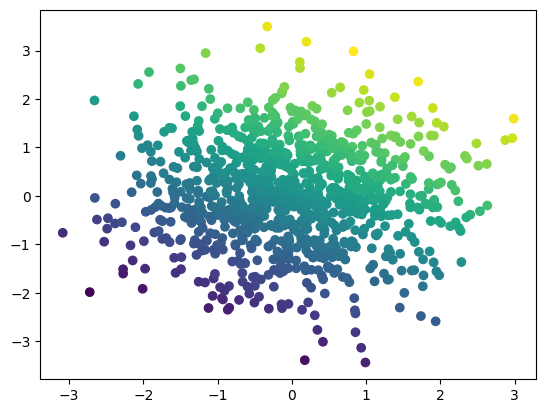

In [14]:
plt.scatter(x=x[:,0],y=x[:,1],c=y) # uncommon method
plt.show()

<Axes: xlabel='0', ylabel='1'>

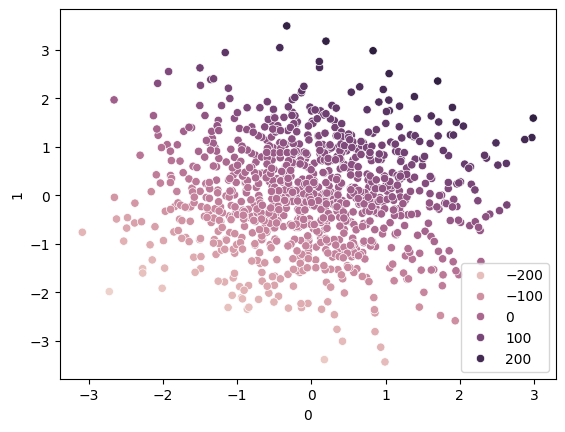

In [15]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=1)

In [17]:
from sklearn.svm import SVR
clf=SVR(kernel='linear')
clf.fit(x_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [18]:
y_pred=clf.predict(x_test)
from sklearn.metrics import r2_score,accuracy_score
r2_score(y_test,y_pred)


0.9986029705091872

In [19]:
# hyper paramter tuning


In [20]:
from sklearn.model_selection import RandomizedSearchCV
params ={'C':[0.1,0.2,0.3,1,2,3,50,100],
         'gamma':[1,.1,.2,.01,.001,.003],
         'kernel':['linear'],
         'epsilon':[.01,.1,.2,.3]}
    

In [21]:
grid=RandomizedSearchCV(clf,param_distributions=params,cv=5,verbose=3)

In [22]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END C=1, epsilon=0.01, gamma=0.001, kernel=linear;, score=0.999 total time=   0.0s
[CV 2/5] END C=1, epsilon=0.01, gamma=0.001, kernel=linear;, score=0.998 total time=   0.0s
[CV 3/5] END C=1, epsilon=0.01, gamma=0.001, kernel=linear;, score=0.998 total time=   0.0s
[CV 4/5] END C=1, epsilon=0.01, gamma=0.001, kernel=linear;, score=0.999 total time=   0.0s
[CV 5/5] END C=1, epsilon=0.01, gamma=0.001, kernel=linear;, score=0.999 total time=   0.0s
[CV 1/5] END C=0.3, epsilon=0.3, gamma=0.01, kernel=linear;, score=0.998 total time=   0.0s
[CV 2/5] END C=0.3, epsilon=0.3, gamma=0.01, kernel=linear;, score=0.998 total time=   0.0s
[CV 3/5] END C=0.3, epsilon=0.3, gamma=0.01, kernel=linear;, score=0.997 total time=   0.0s
[CV 4/5] END C=0.3, epsilon=0.3, gamma=0.01, kernel=linear;, score=0.998 total time=   0.0s
[CV 5/5] END C=0.3, epsilon=0.3, gamma=0.01, kernel=linear;, score=0.998 total time=   0.0s
[CV 1/5] END C=3, e

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR(kernel='linear')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 0.2, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value i

In [23]:
grid.best_params_
grid.best_score_
y_pred_grid=grid.best_estimator_.predict(x_test)
y_pred_grid

array([  57.54907222,  -48.76585667,   58.84289585,  -45.87191623,
         46.55403748,   98.20695463,  -93.73797827,   96.82608715,
         33.09489324,   10.17721502,  -97.03787348,  -29.96905965,
        -59.3443185 ,  -56.57064283,   -1.89979802,  -84.18628936,
         15.70444016,  -78.37313603,   18.06098432,  -13.25887324,
        226.90724618, -122.34105004,  -29.4804089 ,  -53.16543608,
        -65.51618545,   48.28127212, -114.72956311,   71.55300588,
        -79.47925062,    3.96227851,   47.16499477,   -2.37628616,
       -198.14745892,  -29.3899469 , -125.02332532,   21.83074343,
        -37.64069024,   57.16642909,   39.17605636,  -16.73575127,
        137.20841552,  -14.74107304,   53.26313506,  -43.19230239,
         81.82880668,   -8.6222847 ,  233.71596687,  -89.42769763,
         28.66644754,  -15.54615642,  -14.27826551,  -33.09100939,
        114.39744595,  -52.17082826,  -38.71159035, -128.61553698,
         77.13286492,  -18.92040126, -169.40799896,   35.62040

In [24]:
r2_score(y_test,y_pred)

0.9986029705091872